In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set_style("whitegrid")

In [4]:
def plot(data: pd.DataFrame):
    g = sns.displot(
        data=data,
        x="norm",
        col="model",        
        row="layer",        
        kind="hist",   
        height=2.5,         
        aspect=1,       
        stat='probability',
        bins=20,
        common_norm=False,
        common_bins=False,
        edgecolor="white",  
        linewidth=0.5,
        kde=True,
        facet_kws={
            'sharex': False, 
            'sharey': False  
        }
    )

    for ax in g.axes.flatten():
        if not ax.patches and not ax.lines:
            ax.set_visible(False)
        else:
            ax.grid(axis='y', linestyle='--', alpha=0.5)
            ax.grid(axis='x', linestyle='--', alpha=0.5)
            ax.tick_params(labelbottom=True, labelleft=True)

    g.figure.subplots_adjust(hspace=0.5, wspace=0.8)
    plt.savefig("./figs/plot.png", dpi=300)

In [5]:
takes = {
    'pythia-14m': pd.read_csv("../data/2026-02-23-00-06-41_pythia-14m.csv"),
    'pythia-31m': pd.read_csv("../data/2026-02-23-00-06-52_pythia-31m.csv"),
}

data = pd.concat([df.assign(model=model) for model, df in takes.items()], ignore_index=True)

data

,layer,norm,model
0,0,1.187566,pythia-14m
1,0,1.467094,pythia-14m
2,0,1.059013,pythia-14m
3,0,1.012018,pythia-14m
4,0,1.059068,pythia-14m
...,...,...,...
357367,5,34.935448,pythia-31m
357368,5,30.505779,pythia-31m
357369,5,32.533104,pythia-31m
357370,5,24.610119,pythia-31m


FileNotFoundError: [Errno 2] No such file or directory: './figs/plot.png'

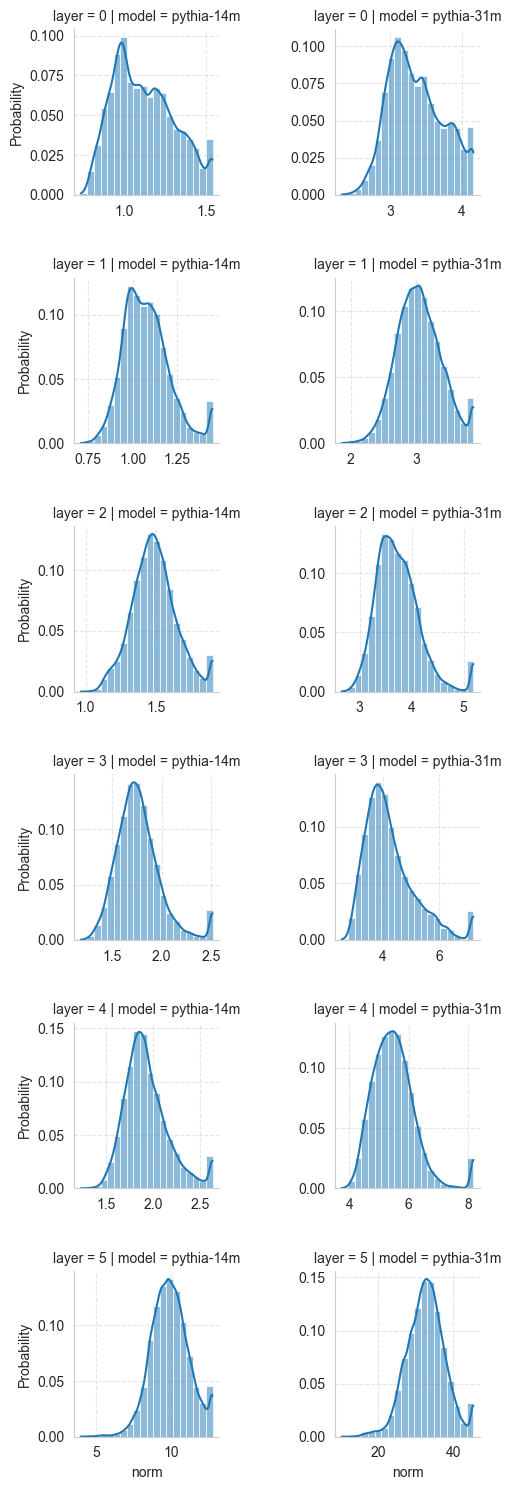

In [7]:
upper_bound = data.groupby(['layer', 'model'])['norm'].transform(lambda x: x.quantile(0.975))

clipped_data = data.copy()
clipped_data['norm'] = clipped_data['norm'].clip(upper=upper_bound)

plot(clipped_data)